# Session 1: Python & Pandas for Bio Tables

## Why this matters

In our final project, we are building an **AI Health Analytics Platform**.

Before we build dashboards or disease prediction models, we need clean data.

Today we will take a raw biological/health dataset and prepare it for analysis and machine learning.

Clean data is important because:
- Dashboards need accurate and understandable information
- Machine learning models learn from the data we give them
- Messy data can lead to incorrect disease predictions
- Clean datasets make future analysis easier and more reliable


## Session Goals

By the end of this session, you will be able to:

1. Load a biological health dataset
2. Inspect rows, columns, and data types
3. Clean column names
4. Check missing values
5. Normalize gene expression columns
6. Compare disease groups
7. Save a cleaned dataset artifact


## 1. Import Libraries

We use libraries so we do not have to write everything from scratch.

In this notebook:

- `pandas` helps us work with tables and CSV files
- `numpy` helps us with numerical operations
- `matplotlib` helps us create simple charts


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Load Dataset

We will load the dataset using `pd.read_csv()`.

Each row represents one patient or sample.

Each column represents information about that patient, such as age, gender, gene expression, smoking status, disease status, and treatment response.


In [ ]:
df = pd.read_csv("Gene Expression Analysis and Disease Relationship.csv")

df.head()

,PatientID,Age,Gender,Gene_X_Expression,Gene_Y_Expression,SmokingStatus,DiseaseStatus,TreatmentResponse
0,1,45,0,5.78,3.21,1,1,1
1,2,62,1,7.12,5.89,2,2,0
2,3,38,0,3.15,1.98,0,0,2
3,4,55,1,6.54,4.76,1,1,1
4,5,71,0,8.01,6.55,2,2,0


## 3. Understand the Dataset

Before cleaning anything, we should first understand the dataset.

We will check:

- How many rows and columns the dataset has
- What the column names are
- What data types each column has
- Basic statistics for numeric columns


In [ ]:
df.shape

(1000, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   PatientID          1000 non-null   int64  
 1   Age                1000 non-null   int64  
 2   Gender             1000 non-null   int64  
 3   Gene_X_Expression  1000 non-null   float64
 4   Gene_Y_Expression  1000 non-null   float64
 5   SmokingStatus      1000 non-null   int64  
 6   DiseaseStatus      1000 non-null   int64  
 7   TreatmentResponse  1000 non-null   int64  
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


In [ ]:
df.describe()

,PatientID,Age,Gender,Gene_X_Expression,Gene_Y_Expression,SmokingStatus,DiseaseStatus,TreatmentResponse
count,1000.000000,1000.000000,1000.00000,1000.00000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,49.631000,0.50000,3.92314,3.62837,0.058000,0.058000,1.942000
std,288.819436,17.608774,0.50025,2.00056,1.94636,0.307784,0.307784,0.307784
min,1.000000,20.000000,0.00000,0.51000,0.30000,0.000000,0.000000,0.000000
25%,250.750000,34.000000,0.00000,2.19750,1.95000,0.000000,0.000000,2.000000
50%,500.500000,49.000000,0.50000,3.88500,3.58500,0.000000,0.000000,2.000000
75%,750.250000,65.000000,1.00000,5.61250,5.33000,0.000000,0.000000,2.000000
max,1000.000000,80.000000,1.00000,9.01000,7.55000,2.000000,2.000000,2.000000


Important columns in this dataset may include:

- `PatientID`
- `Age`
- `Gender`
- `Gene_X_Expression`
- `Gene_Y_Expression`
- `SmokingStatus`
- `DiseaseStatus`
- `TreatmentResponse`

These columns can help us build a health analytics dashboard and later train a disease classification model.


### Practice

Try these tasks yourself before looking at examples later.


In [ ]:
# Practice:
# 1. Show the first 10 rows
# 2. Show the column names
# 3. Show the number of rows and columns


In [ ]:
df.head(10)

,PatientID,Age,Gender,Gene_X_Expression,Gene_Y_Expression,SmokingStatus,DiseaseStatus,TreatmentResponse
0,1,45,0,5.78,3.21,1,1,1
1,2,62,1,7.12,5.89,2,2,0
2,3,38,0,3.15,1.98,0,0,2
3,4,55,1,6.54,4.76,1,1,1
4,5,71,0,8.01,6.55,2,2,0
5,6,30,1,2.87,1.54,0,0,2
6,7,49,0,6.22,4.01,1,1,1
7,8,68,1,7.56,6.12,2,2,0
8,9,33,0,3.44,2.11,0,0,2
9,10,59,1,6.89,5.33,1,1,1


In [ ]:
df.columns

Index(['PatientID', 'Age', 'Gender', 'Gene_X_Expression', 'Gene_Y_Expression',
       'SmokingStatus', 'DiseaseStatus', 'TreatmentResponse'],
      dtype='object')

## 4. Clean Column Names

Column names are often messy in real datasets.

For example, a dataset may have:
- Spaces
- Capital letters
- Extra whitespace

Clean column names make the dataset easier to use in code.

Example:

`Gene_X_Expression` becomes `gene_x_expression`


In [ ]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

df.columns

Index(['patientid', 'age', 'gender', 'gene_x_expression', 'gene_y_expression',
       'smokingstatus', 'diseasestatus', 'treatmentresponse'],
      dtype='object')

## 5. Check Missing Values

Missing values are common in real health and biology datasets.

Missing data can happen because:
- A lab test failed
- A patient record was incomplete
- A measurement was not collected
- Data was entered incorrectly

Before training a model, we need to know whether missing values exist.


In [ ]:
df.isna().sum()

,0
patientid,0
age,0
gender,0
gene_x_expression,0
gene_y_expression,0
smokingstatus,0
diseasestatus,0
treatmentresponse,0


In [ ]:
df.isna().mean() * 100

,0
patientid,0.0
age,0.0
gender,0.0
gene_x_expression,0.0
gene_y_expression,0.0
smokingstatus,0.0
diseasestatus,0.0
treatmentresponse,0.0


### Practice


In [ ]:
# Practice:
# Check if any column has missing values.
# Print the percentage of missing values for each column.


In [ ]:
df.isna().sum()

,0
PatientID,0
Age,0
Gender,0
Gene_X_Expression,0
Gene_Y_Expression,0
SmokingStatus,0
DiseaseStatus,0
TreatmentResponse,0


## 6. Understand Encoded Columns

Some columns may be stored as numbers but actually represent categories.

For example:

- `Gender`
- `SmokingStatus`
- `DiseaseStatus`
- `TreatmentResponse`

This is common in machine learning datasets because models often work better with numbers.

However, for human understanding and dashboards, labels are easier to read.


In [ ]:
df.head()

,patientid,age,gender,gene_x_expression,gene_y_expression,smokingstatus,diseasestatus,treatmentresponse
0,1,45,0,5.78,3.21,1,1,1
1,2,62,1,7.12,5.89,2,2,0
2,3,38,0,3.15,1.98,0,0,2
3,4,55,1,6.54,4.76,1,1,1
4,5,71,0,8.01,6.55,2,2,0


## 7. Map Encoded Values to Labels

Here we create readable labels for encoded categorical columns.

This helps us understand the dataset better and makes visualizations easier to interpret.

Note: Always confirm encoding meanings from the dataset documentation when available.


In [ ]:
gender_map = {
    0: "female",
    1: "male"
}

smoking_map = {
    0: "non_smoker",
    1: "former_smoker",
    2: "current_smoker"
}

disease_map = {
    0: "healthy",
    1: "mild_disease",
    2: "severe_disease"
}

response_map = {
    0: "no_response",
    1: "partial_response",
    2: "good_response"
}

df["gender_label"] = df["gender"].map(gender_map)
df["smoking_status_label"] = df["smokingstatus"].map(smoking_map)
df["disease_status_label"] = df["diseasestatus"].map(disease_map)
df["treatment_response_label"] = df["treatmentresponse"].map(response_map)

df.head()

,patientid,age,gender,gene_x_expression,gene_y_expression,smokingstatus,diseasestatus,treatmentresponse,gender_label,smoking_status_label,disease_status_label,treatment_response_label
0,1,45,0,5.78,3.21,1,1,1,female,former_smoker,mild_disease,partial_response
1,2,62,1,7.12,5.89,2,2,0,male,current_smoker,severe_disease,no_response
2,3,38,0,3.15,1.98,0,0,2,female,non_smoker,healthy,good_response
3,4,55,1,6.54,4.76,1,1,1,male,former_smoker,mild_disease,partial_response
4,5,71,0,8.01,6.55,2,2,0,female,current_smoker,severe_disease,no_response


## 8. Normalize Gene Expression

Gene expression values can be on different scales.

Normalization helps us compare values more fairly.

Here we use standardization:

\[
z = \frac{x - \text{mean}}{\text{standard deviation}}
\]

After normalization:
- Values around 0 are close to average
- Positive values are above average
- Negative values are below average


In [ ]:
df["gene_x_expression_norm"] = (
    df["gene_x_expression"] - df["gene_x_expression"].mean()
) / df["gene_x_expression"].std()

df["gene_y_expression_norm"] = (
    df["gene_y_expression"] - df["gene_y_expression"].mean()
) / df["gene_y_expression"].std()

df.head()

,patientid,age,gender,gene_x_expression,gene_y_expression,smokingstatus,diseasestatus,treatmentresponse,gender_label,smoking_status_label,disease_status_label,treatment_response_label,gene_x_expression_norm,gene_y_expression_norm
0,1,45,0,5.78,3.21,1,1,1,female,former_smoker,mild_disease,partial_response,0.928170,-0.214950
1,2,62,1,7.12,5.89,2,2,0,male,current_smoker,severe_disease,no_response,1.597982,1.161979
2,3,38,0,3.15,1.98,0,0,2,female,non_smoker,healthy,good_response,-0.386462,-0.846899
3,4,55,1,6.54,4.76,1,1,1,male,former_smoker,mild_disease,partial_response,1.308064,0.581408
4,5,71,0,8.01,6.55,2,2,0,female,current_smoker,severe_disease,no_response,2.042858,1.501074


## 9. Compare Groups

Now we can ask simple biological questions.

For example:

> Do patients with different disease statuses have different average gene expression values?

Group comparison is important because it helps us find patterns before building machine learning models.


In [ ]:
df.groupby("disease_status_label")["gene_x_expression"].mean()

,gene_x_expression
disease_status_label,
healthy,3.793160
mild_disease,6.402778
severe_disease,7.943500


In [ ]:
df.groupby("disease_status_label")["gene_y_expression"].mean()

,gene_y_expression
disease_status_label,
healthy,3.550437
mild_disease,4.581667
severe_disease,6.519000


## 10. Visualize Group Differences

Tables are useful, but charts make patterns easier to see.

Here we create bar charts to compare average gene expression across disease groups.


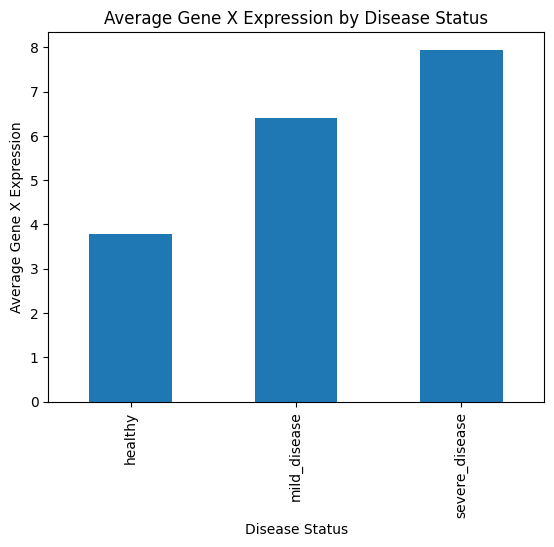

In [ ]:
df.groupby("disease_status_label")["gene_x_expression"].mean().plot(kind="bar")

plt.title("Average Gene X Expression by Disease Status")
plt.xlabel("Disease Status")
plt.ylabel("Average Gene X Expression")
plt.show()

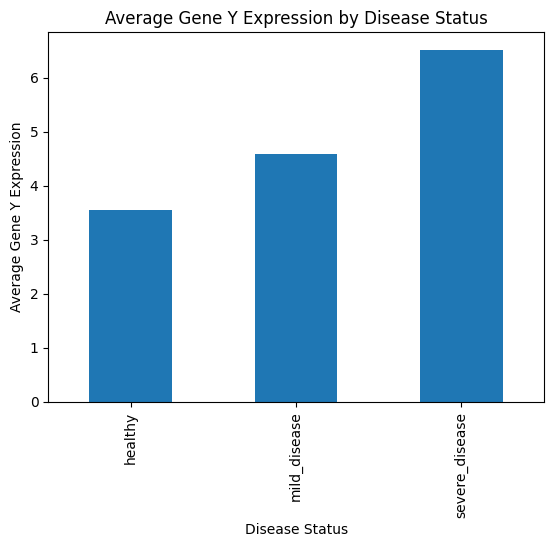

In [ ]:
df.groupby("disease_status_label")["gene_y_expression"].mean().plot(kind="bar")

plt.title("Average Gene Y Expression by Disease Status")
plt.xlabel("Disease Status")
plt.ylabel("Average Gene Y Expression")
plt.show()

### Practice


In [ ]:
# Practice:
# Compare average age by disease group.
# Then create a bar chart for it.


## 11. Build Clean Dataset

Now we create a cleaner dataset that is easier to understand and ready for future analysis.

This cleaned dataset will be used later for:
- Dataset explorer dashboard
- Disease classification model
- Model interpretability


In [ ]:
clean_df = df[
    [
        "patientid",
        "age",
        "gender_label",
        "smoking_status_label",
        "disease_status_label",
        "treatment_response_label",
        "gene_x_expression",
        "gene_y_expression",
        "gene_x_expression_norm",
        "gene_y_expression_norm"
    ]
]

clean_df.head()

,patientid,age,gender_label,smoking_status_label,disease_status_label,treatment_response_label,gene_x_expression,gene_y_expression,gene_x_expression_norm,gene_y_expression_norm
0,1,45,female,former_smoker,mild_disease,partial_response,5.78,3.21,0.928170,-0.214950
1,2,62,male,current_smoker,severe_disease,no_response,7.12,5.89,1.597982,1.161979
2,3,38,female,non_smoker,healthy,good_response,3.15,1.98,-0.386462,-0.846899
3,4,55,male,former_smoker,mild_disease,partial_response,6.54,4.76,1.308064,0.581408
4,5,71,female,current_smoker,severe_disease,no_response,8.01,6.55,2.042858,1.501074


## 12. Save Cleaned Dataset

The cleaned dataset is our output artifact.

This file can be reused in future sessions without repeating all the cleaning steps manually.


In [ ]:
clean_df.to_csv("cleaned_bio_health_data.csv", index=False)

## Session Wrap-Up

In this session, we:

1. Loaded a biological health dataset
2. Inspected the data structure
3. Cleaned column names
4. Checked for missing values
5. Added readable labels for encoded categories
6. Normalized gene expression columns
7. Compared disease groups
8. Saved a cleaned dataset artifact

This is the foundation for the future AI Health Analytics Platform.


# Visualization & Interpretation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("cleaned_bio_health_data.csv")
df.head()

,patientid,age,gender_label,smoking_status_label,disease_status_label,treatment_response_label,gene_x_expression,gene_y_expression,gene_x_expression_norm,gene_y_expression_norm
0,1,45,female,former_smoker,mild_disease,partial_response,5.78,3.21,0.928170,-0.214950
1,2,62,male,current_smoker,severe_disease,no_response,7.12,5.89,1.597982,1.161979
2,3,38,female,non_smoker,healthy,good_response,3.15,1.98,-0.386462,-0.846899
3,4,55,male,former_smoker,mild_disease,partial_response,6.54,4.76,1.308064,0.581408
4,5,71,female,current_smoker,severe_disease,no_response,8.01,6.55,2.042858,1.501074


In [ ]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patientid                 1000 non-null   int64  
 1   age                       1000 non-null   int64  
 2   gender_label              1000 non-null   object 
 3   smoking_status_label      1000 non-null   object 
 4   disease_status_label      1000 non-null   object 
 5   treatment_response_label  1000 non-null   object 
 6   gene_x_expression         1000 non-null   float64
 7   gene_y_expression         1000 non-null   float64
 8   gene_x_expression_norm    1000 non-null   float64
 9   gene_y_expression_norm    1000 non-null   float64
dtypes: float64(4), int64(2), object(4)
memory usage: 78.3+ KB


,patientid,age,gene_x_expression,gene_y_expression,gene_x_expression_norm,gene_y_expression_norm
count,1000.000000,1000.000000,1000.00000,1000.00000,1.000000e+03,1.000000e+03
mean,500.500000,49.631000,3.92314,3.62837,-4.618528e-17,6.350476e-17
std,288.819436,17.608774,2.00056,1.94636,1.000000e+00,1.000000e+00
min,1.000000,20.000000,0.51000,0.30000,-1.706092e+00,-1.710049e+00
25%,250.750000,34.000000,2.19750,1.95000,-8.625784e-01,-8.623122e-01
50%,500.500000,49.000000,3.88500,3.58500,-1.906466e-02,-2.228262e-02
75%,750.250000,65.000000,5.61250,5.33000,8.444434e-01,8.742628e-01
max,1000.000000,80.000000,9.01000,7.55000,2.542718e+00,2.014853e+00


# Boxplot: Gene Expression by Disease Group

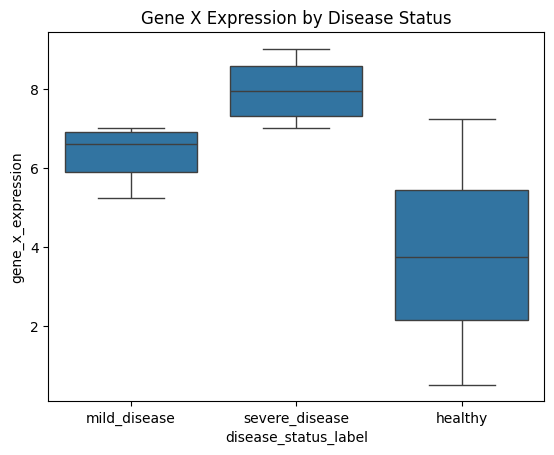

In [ ]:
sns.boxplot(data=df, x="disease_status_label", y="gene_x_expression")
plt.title("Gene X Expression by Disease Status")
plt.show()

### Interpretation

This boxplot helps us compare Gene X expression across disease groups.

Why this matters:

- **Median (middle line)**  
  The median shows the typical gene expression level for each group.  
  If one disease group has a higher median, it suggests that this gene may be associated with disease severity.

- **Spread (box + whiskers)**  
  The spread shows how much variability exists within each group.  
  A wider spread means the gene behaves differently across patients, which could indicate biological diversity or noise in measurements.

- **Outliers (points outside the whiskers)**  
  Outliers may represent:
  - unusual patients
  - rare biological cases
  - measurement errors  

  These are important because they can strongly influence machine learning models.

Overall:

We are trying to understand whether Gene X expression is **consistently different across disease groups**, which would make it a useful feature for disease prediction.

# Scatter Plot: Gene X vs Gene Y

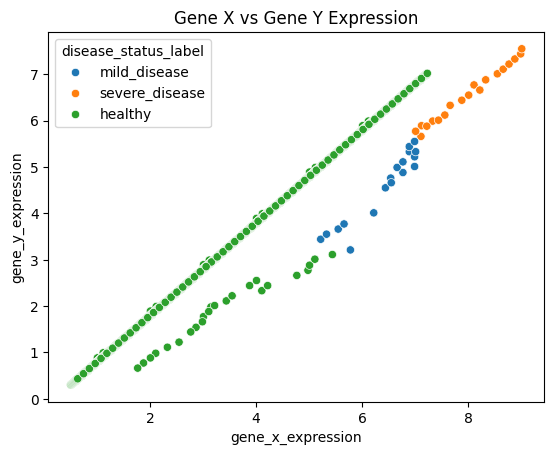

In [ ]:
sns.scatterplot(
    data=df,
    x="gene_x_expression",
    y="gene_y_expression",
    hue="disease_status_label"
)

plt.title("Gene X vs Gene Y Expression")
plt.show()

### Interpretation

This plot helps us understand how Gene X and Gene Y behave together.

Why this matters:

- **Do the genes move together?**  
  If points form a pattern (like a line), it means when one gene increases, the other also increases (or decreases).  
  This tells us the genes might be related.

- **Do disease groups separate?**  
  If different disease groups form clusters (separate colored regions), it means these genes might help distinguish between healthy and diseased patients.

- **Are points mixed or separated?**  
  If all colors are mixed together, the genes may not be useful for predicting disease.  
  If they are clearly separated, these genes could be strong predictors.

Overall:

We are checking whether these genes show patterns that can help us understand or predict disease.

# Scatter Plot: Age vs Gene Expression

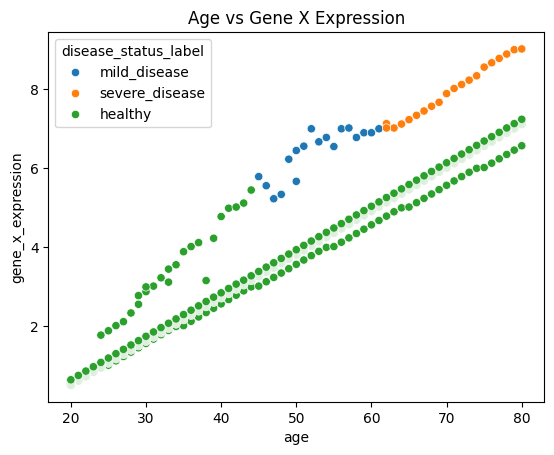

In [ ]:
sns.scatterplot(
    data=df,
    x="age",
    y="gene_x_expression",
    hue="disease_status_label"
)

plt.title("Age vs Gene X Expression")
plt.show()

### Why this matters

We are checking if age is influencing what we see in the data.

Example:

If older patients tend to:
- have more severe disease  
- AND have different gene expression  

then the pattern we see might not be because of the disease alone —  
it might be partly because of age.

This is important because:

When we build a prediction model, we want it to learn the **real reason** behind the pattern.

If we ignore age, the model might make incorrect conclusions.

# Heatmap: Correlation Between Numeric Columns

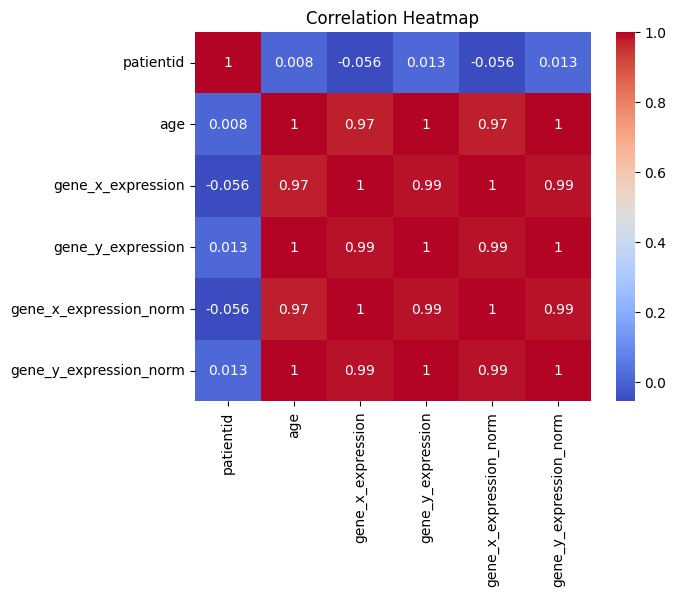

In [ ]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

corr = numeric_df.corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Interpretation

This heatmap shows how different numerical features are related to each other.

Why this matters:

- **What do the colors mean?**  
  Each cell shows how strongly two variables are related.  
  - Dark/red color → strong relationship  
  - Light/blue color → weak or no relationship  

- **Positive vs negative relationship**  
  - Positive → both increase together  
  - Negative → one increases while the other decreases  

- **Why do we care?**  
  If two features are strongly related, they may be giving similar information.

Example:
If `gene_x_expression` and `gene_y_expression` are highly related,  
we might not need both for prediction.

- **Look for important patterns**  
  - Which features are strongly related to each other?  
  - Are gene expressions related to age?  
  - Are normalized and original values strongly related?  

Overall:

We are using this heatmap to understand relationships between features before building a model, so we don’t use redundant or misleading information.

## What is a Confounder?

A confounder is a variable that affects both the input and the outcome.

Example:

If age is related to disease status and also related to gene expression, then age may influence the relationship between gene expression and disease.

This matters because our model might learn the wrong reason for prediction.